# Lab 9: Feature Scaling and Encoding

## Exercise 1: Life Expectancy Dataset

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

### a. Load the dataset using pandas.read_csv()

In [2]:
df = pd.read_csv("Life_Expectancy_Data.csv")

### b.​ Display the first 5 rows

In [3]:
df.head()

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


### c.​ Use df.info() and df.describe() to get a basic understanding

In [4]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             2938 non-null   int64  
 1   Status                           2938 non-null   object 
 2   Life expectancy                  2928 non-null   float64
 3   Adult Mortality                  2928 non-null   float64
 4   infant deaths                    2938 non-null   int64  
 5   Alcohol                          2744 non-null   float64
 6   percentage expenditure           2938 non-null   float64
 7   Hepatitis B                      2385 non-null   float64
 8   Measles                          2938 non-null   int64  
 9   BMI                              2904 non-null   float64
 10  under-five deaths                2938 non-null   int64  
 11  Polio                            2919 non-null   float64
 12  Total expenditure   

### d.​ Check how many missing values are present per column.

In [5]:
df.isnull().sum()

Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
thinness  1-19 years                34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
dtype: int64

### e.​ Drop ‘Population’ and ‘GDP’ columns.

In [6]:
df = df.drop(columns=["Population", "GDP"])

### f.​ For the remaining missing values:
■​ Fill numerical columns using median.
■​ Fill categorical columns (like "Status") using mode.

In [7]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
categorical_cols = df.select_dtypes(exclude="number").columns.tolist()

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

### g.​ Check the dataset size after dropping.

In [8]:
print("Size:", df.size)
print("Shape:", df.shape)

Size: 55822
Shape: (2938, 19)


### h.​ Check if any duplicate rows exist

In [9]:
df.duplicated().sum()

np.int64(0)

### i.​ Remove them using drop_duplicates()

In [10]:
df = df.drop_duplicates()

### j.​ Check the dataset size after dropping.

In [11]:
print("Size:", df.size)
print("Shape:", df.shape)

Size: 55822
Shape: (2938, 19)


### k.​ List all numerical columns

In [12]:
print(f"Numerical cols: {numeric_cols}")

Numerical cols: ['Year', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


### l.​ Apply suitable feature scaling technique on each numerical column and mention why you choose it.

In [13]:
skew_values = df[numeric_cols].skew()
skew_values

Year                              -0.006409
Life expectancy                   -0.642391
Adult Mortality                    1.177899
infant deaths                      9.786963
Alcohol                            0.649578
percentage expenditure             4.652051
Hepatitis B                       -2.281697
Measles                            9.441332
BMI                               -0.229157
under-five deaths                  9.495065
Polio                             -2.108909
Total expenditure                  0.661108
Diphtheria                        -2.083566
HIV/AIDS                           5.396112
thinness  1-19 years               1.729496
thinness 5-9 years                 1.795694
Income composition of resources   -1.212526
Schooling                         -0.635052
dtype: float64

In [14]:
# Skewness is >= 1 and <= -1 so we use Standardization
scaler = StandardScaler()
scaler.fit_transform(df[numeric_cols])

array([[ 1.6217623 , -0.44540826,  0.79211913, ...,  2.77538573,
        -0.73797341, -0.58501698],
       [ 1.40498625, -0.98182707,  0.85660141, ...,  2.81997792,
        -0.75260009, -0.61564876],
       [ 1.1882102 , -0.98182707,  0.83242056, ...,  2.86457011,
        -0.78185344, -0.64628054],
       ...,
       [-1.19632639, -2.57004747, -0.73933497, ..., -0.79198947,
        -0.99150247, -0.61564876],
       [-1.41310244, -2.51745739,  4.20161958, ..., -0.70280509,
        -0.99150247, -0.67691233],
       [-1.62987849, -2.44383128,  4.0323536 , ...,  1.41532393,
        -0.95737356, -0.67691233]], shape=(2938, 18))

### m.​ List all the categorical columns

In [15]:
print(f"Categorical columns: {categorical_cols}")

Categorical columns: ['Status']


### n.​ Apply suitable feature encoding technique on each categorical column and mention why you choose it.

In [16]:
# Exactly two unique values, Developing and Developed, so Label Encoding is the most suitable
le = LabelEncoder()

df['Status'] = le.fit_transform(df['Status'].values.ravel())

### o.​ Create a line plot showing how Life expectancy changes from 2011 to 2015.

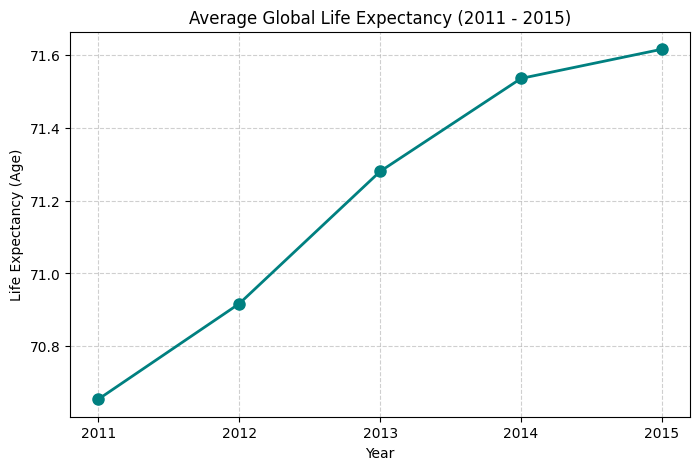

In [17]:
df_years = df[(df['Year'] >= 2011) & (df['Year'] <= 2015)]

yearly_avg = df_years.groupby('Year')['Life expectancy'].mean()

plt.figure(figsize=(8, 5))
yearly_avg.plot(kind='line', marker='o', color='teal',
                linewidth=2, markersize=8)

plt.title('Average Global Life Expectancy (2011 - 2015)')
plt.xlabel('Year')
plt.ylabel('Life Expectancy (Age)')
plt.xticks([2011, 2012, 2013, 2014, 2015])
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### p.​ Create a grouped bar chart comparing the following variables across years:
■​ infant deaths
■​ under-five deaths
■​ Adult Mortality

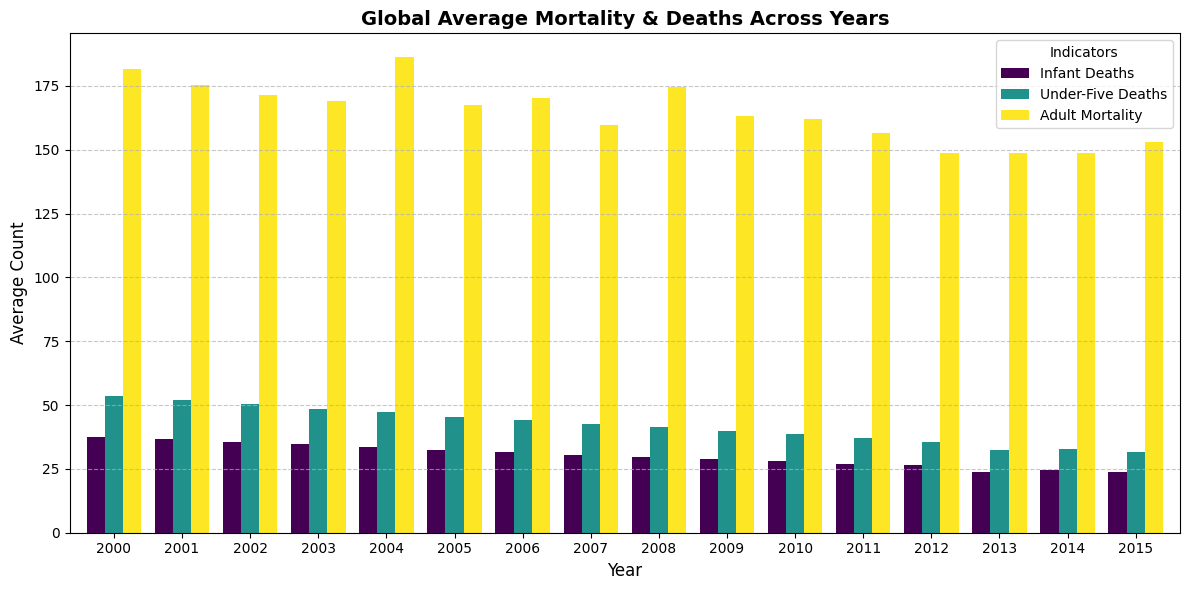

In [18]:
columns_to_plot = ['infant deaths', 'under-five deaths', 'Adult Mortality']

yearly_avg_deaths = df.groupby('Year')[columns_to_plot].mean()

yearly_avg_deaths.plot(kind='bar', figsize=(
    12, 6), width=0.8, colormap='viridis')

plt.title('Global Average Mortality & Deaths Across Years',
          fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Count', fontsize=12)

plt.xticks(rotation=0)

plt.legend(['Infant Deaths', 'Under-Five Deaths',
           'Adult Mortality'], title='Indicators')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### q.​ Visualize a correlation heatmap for all numerical features, identify the features that are highly correlated with Life expectancy (based on absolute correlation values), determine the top 3 least correlated features with respect to Life expectancy, and drop those least correlated features from the dataset.

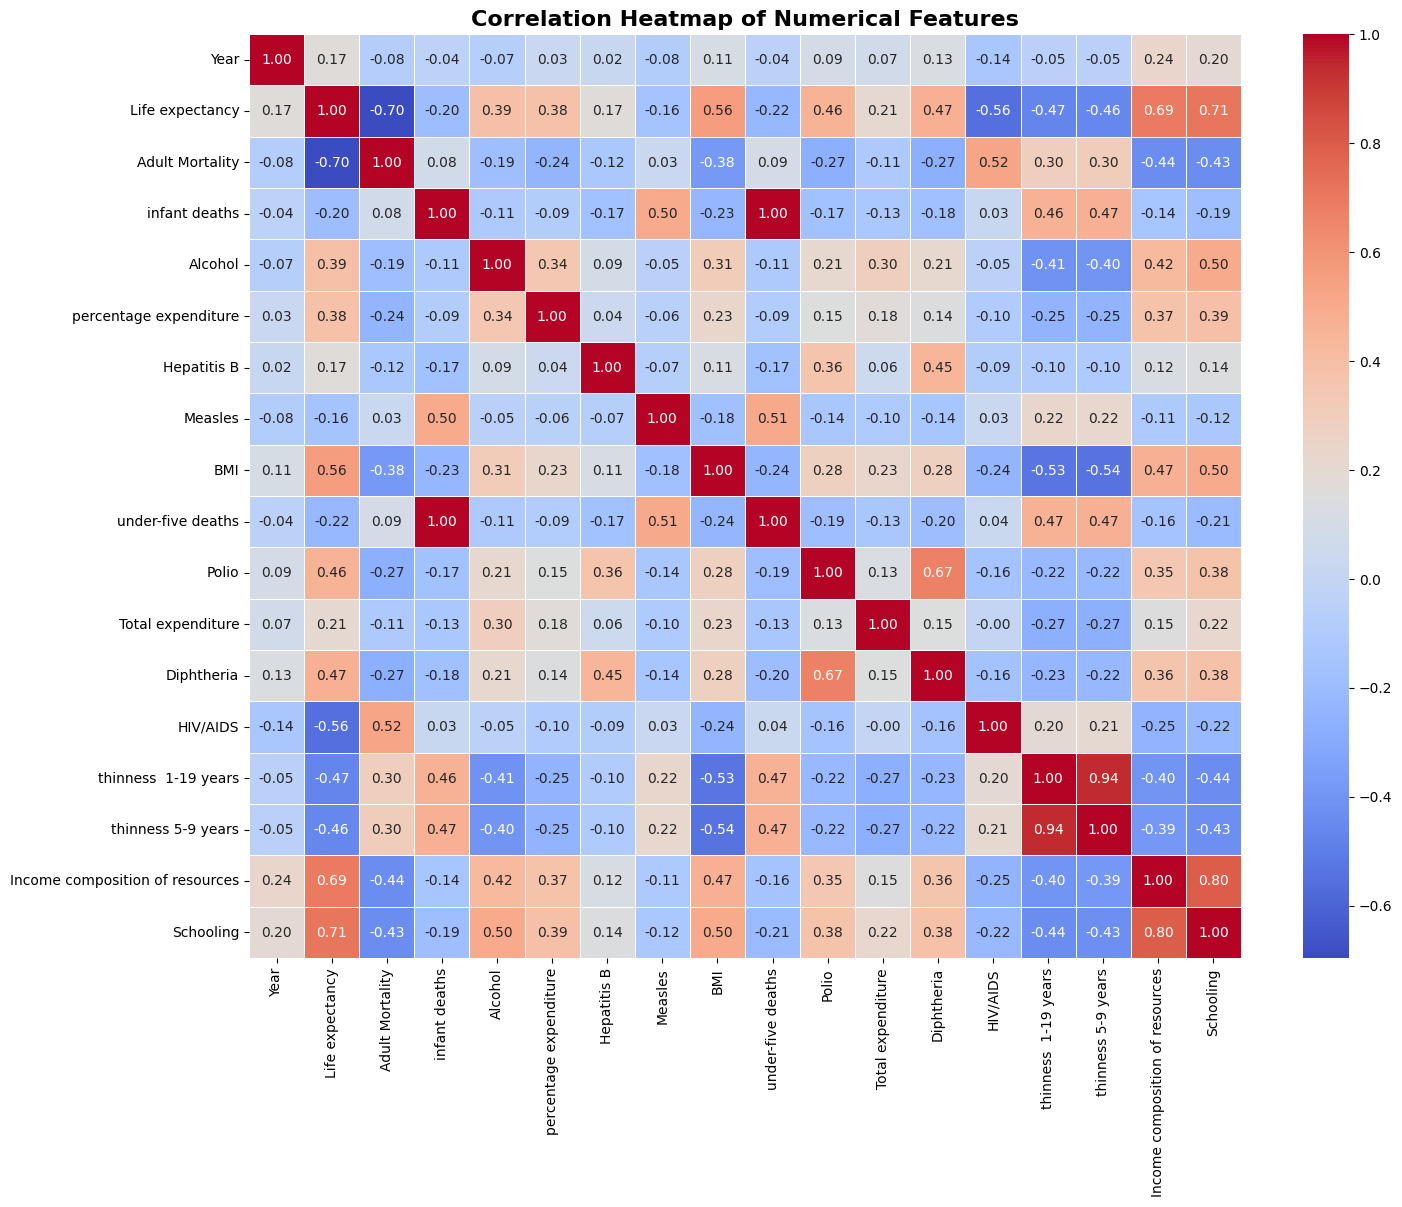

In [19]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features',
          fontsize=16, fontweight='bold')
plt.show()

In [20]:
life_exp_corr = corr_matrix['Life expectancy'].abs(
).sort_values(ascending=False)
print("Absolute Correlation with Life Expectancy:")
print(life_exp_corr)

Absolute Correlation with Life Expectancy:
Life expectancy                    1.000000
Schooling                          0.713054
Adult Mortality                    0.696390
Income composition of resources    0.688662
BMI                                0.556901
HIV/AIDS                           0.556703
Diphtheria                         0.472211
thinness  1-19 years               0.468002
thinness 5-9 years                 0.462473
Polio                              0.458399
Alcohol                            0.388918
percentage expenditure             0.381418
under-five deaths                  0.222738
Total expenditure                  0.208844
infant deaths                      0.196769
Year                               0.170819
Hepatitis B                        0.170219
Measles                            0.157767
Name: Life expectancy, dtype: float64


In [21]:
least_correlated_features = life_exp_corr.tail(3).index.tolist()
print(f"\n3 least correlated features to drop: {
      least_correlated_features}")


3 least correlated features to drop: ['Year', 'Hepatitis B', 'Measles']


In [22]:
df = df.drop(columns=least_correlated_features)

### r.​ Save the cleaned dataset as cleaned.csv.

In [23]:
df.to_csv('cleaned.csv', index=False)

## 2.​ Consider a sample dataset below

In [24]:
data = {
    "Age": ["25", "30", "35", "40", "45"],
    "Income": ["$1000.5", "$1500.0", "$2000.75", "?", "$3000.25"],
    "Signup_Date": [
        "2023-01-15",
        "2023-02-20",
        "2023-03-25",
        "2023-04-30",
        "2023-05-05",
    ],
    "Color": ["Red", "Blue", "Green", "Red", "Blue"],
    "Score": [85, 90, 78, 92, 88],
}
df = pd.DataFrame(data)
df

,Age,Income,Signup_Date,Color,Score
0,25,$1000.5,2023-01-15,Red,85
1,30,$1500.0,2023-02-20,Blue,90
2,35,$2000.75,2023-03-25,Green,78
3,40,?,2023-04-30,Red,92
4,45,$3000.25,2023-05-05,Blue,88


### Convert each of the given columns in a suitable datatype after cleaning. Display the data type of all columns before and after conversion

In [25]:
df.dtypes

Age            object
Income         object
Signup_Date    object
Color          object
Score           int64
dtype: object

In [26]:
df['Age'] = df['Age'].astype(int)

In [28]:
df['Income'] = df['Income'].replace('?', np.nan)
df['Income'] = df['Income'].str.replace('$', '', regex=False).astype(float)

In [29]:
df['Signup_Date'] = pd.to_datetime(df['Signup_Date'])
df['Color'] = df['Color'].astype('category')
df['Score'] = df['Score'].astype(int)

In [31]:
df.dtypes

Age                     int64
Income                float64
Signup_Date    datetime64[ns]
Color                category
Score                   int64
dtype: object

In [32]:
df

,Age,Income,Signup_Date,Color,Score
0,25,1000.50,2023-01-15,Red,85
1,30,1500.00,2023-02-20,Blue,90
2,35,2000.75,2023-03-25,Green,78
3,40,NaN,2023-04-30,Red,92
4,45,3000.25,2023-05-05,Blue,88
